::: {.callout-tip collapse="true"}
#### TLDR

Some models quantize better than others, in this case it was EfficientNetB0 and ResNet18 (the latter quantized better).

The issue is that the range of activation values of the EfficientNetB0 network is quite large, this is caused by the architecture, so when they are cast to INT8 values the error is large. 

Therefore, when training your own models then if quantization is in the pipeline, check the ranges of activation values <b>post training</b> if the range is large you might see issues with quantization.

<b>NOTE</b>: You must check the values post training as at init time the model might not display the same activation behaviour.

:::

::: {.glossary}
Glossary

ENB0
: EfficientNetB0

RN18
: ResNet18
:::

---

## A case study on Quantizing EfficientNetB0 and ResNet18

Quantization was employed in an effort to speedup and reduce the battery usage[<sup>5</sup>](#5) of the model used in EyesOff (EfficientNet_B0). However, when testing the quantized model on the benchmark the accuracy dropped massively (from <b>~90% to ~34%</b>). This sparked a journey to understand why ENB0 quantizes poorly and why another model (RN18) quantizes well.

Let's start with the benchmarking.

::: {.callout-tip collapse="false"}

#### Quantization Theory Overview

It's useful to look into some of theory of quantization before diving deep into experiments, it will become especially useful later.

The goal of quantization is to convert a FloatingPoint32 (FP32) model into an 8-bit integer (INT8) model. I.e. the weights and activations of the model are cast to INT8, however it is not a simple cast. By doing this we gain speed, efficiency and a reduction in memory usage - at the cost of some accuracy (depending on the model...).

So for a given model, we will have a range of FP32 values $[a, b]$ and the goal is to convert this range into the INT8 space. Now imagine a value $x$, which belongs to the range $[a, b]$. This $x$ can be defined by the following quantization scheme: 

$$
x = S * (x_{q} - Z)
$$

Where:

- $x_{q}$ = INT8 Quantized $x$
- $S$ = Scale factor (a positive FP32 value)
- $Z$ = Zero point, the INT8 value corresponding to 0 in the FP32 realm.

Therefore, $x_{q}$ can be defined as:

$$
x_{q} = round(\frac{x}{S} + Z)
$$

##### Quantization calibration

We've discussed $[a, b]$ a bit already, but how do we actually get these values? For weights it is easy, as weights are fixed and are known ahead of time, it becomes trickier when considering activations which may vary based on the input. This is the point of calibration and there are three types of calibration:

• <b>Post-Training Dynamic Quantization</b> - the range for each activation is computed on the fly at inference time, this method is very accurate however it can be slower due to the overhead of on the fly computations.

• <b>Static Quantization</b> (what I use in this post) - range computed in advance at quantization time. By passing representative examples (training data for example) we can calculate the expected range of FP32 activation values ahead of time. This is much quicker but does come at the cost of some accuracy, as the ranges are only as good as the examples we provide - think of general issues with generalisability and OOD samples.

• <b>Quantization Aware Training</b> - the range for each activation is computed at training time. It's similar to static, but it is a bit more involved.

Now one simple way to actually calculate the range $[a, b]$ is to take the worst case of minimum value and maximum value when calibrating the model. Refer to the further reading for other approaches[<sup>1</sup>](#1).

Further reading on quantization:
<a href="https://leimao.github.io/article/Neural-Networks-Quantization/">https://leimao.github.io/article/Neural-Networks-Quantization/</a>

<a href="https://arxiv.org/abs/1712.05877">https://arxiv.org/abs/1712.05877</a>

:::

### Benchmarking the EfficientNetB0 Quantization

#### Quantizing the PyTorch Model

In the expandable box you will find the code to quantize the model, taking a .pth model and outputting an INT8 quantized .onnx model.

In [171]:
#| code-fold: true
#| code-summary: "Quantize the model"

# Code to quantize the model
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import time

import cv2
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
import onnxruntime as ort
from onnxruntime.quantization.preprocess import quant_pre_process
from onnxruntime.quantization import (
    quantize_static,
    QuantType,
    QuantFormat,
    CalibrationDataReader
)

INPUT_PTH_PATH = "./model.pth"
OUTPUT_ONNX_PATH = "./model.onnx"
IMG_SIZE = 224

def build_efficientnet_b0():
    """Build EfficientNet-B0 with custom binary classification head."""
    model = models.efficientnet_b0(weights=None)
    model.classifier = nn.Sequential(
        nn.Dropout(0.6),
        nn.Linear(1280, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.6),
        nn.Linear(128, 1),
    )
    return model

def convert_pth_to_onnx(pth_path, onnx_path, img_size=224):
    """
    Convert PyTorch model to ONNX.

    Args:
        pth_path: Path to .pth weights file
        onnx_path: Output path for .onnx file
        model_name: Architecture name (must match training)
        img_size: Input image size
    """
    print(f"\n{'='*60}")
    print("PyTorch → ONNX Conversion")
    print('='*60)
    print(f"  Input:  {pth_path}")
    print(f"  Output: {onnx_path}")

    model = build_efficientnet_b0()

    # Load weights
    state_dict = torch.load(pth_path, map_location='cpu', weights_only=False)
    if isinstance(state_dict, dict) and 'model_state_dict' in state_dict:
        state_dict = state_dict['model_state_dict']

    model.load_state_dict(state_dict)
    model.eval()

    # Create dummy input
    dummy_input = torch.randn(1, 3, img_size, img_size)

    # Export to ONNX
    torch.onnx.export(
        model,
        dummy_input,
        onnx_path,
        export_params=True,
        opset_version=21,
        do_constant_folding=True,
        input_names=['input'],
        output_names=['output'],
        dynamic_axes={
            'input': {0: 'batch_size'},
            'output': {0: 'batch_size'}
        },
		dynamo=False,
    )

    # Verify
    import onnx
    onnx_model = onnx.load(onnx_path)
    onnx.checker.check_model(onnx_model)

    size_mb = Path(onnx_path).stat().st_size / (1024 * 1024)
    print(f"  ✓ Conversion complete")
    print(f"  Size: {size_mb:.2f} MB")

    return onnx_path

convert_pth_to_onnx(INPUT_PTH_PATH, OUTPUT_ONNX_PATH, IMG_SIZE)

# Preprocess the onnx model to further optimize
INPUT_ONNX_PATH = "./model.onnx"
OUTPUT_PREPROCESSED_PATH = "./model_preprocessed.onnx"

def preprocess_for_quantization(input_path, output_path):
    """
    Preprocess ONNX model for better quantization results.

    This step performs:
    - Symbolic shape inference
    - ONNX Runtime optimization (fuses Conv+BN, etc.)
    - ONNX shape inference

    Args:
        input_path: Path to input ONNX model
        output_path: Path for preprocessed output

    Returns:
        output_path on success
    """
    print(f"\n{'='*60}")
    print("ONNX Preprocessing for Quantization")
    print('='*60)
    print(f"  Input:  {input_path}")
    print(f"  Output: {output_path}")

    try:
        quant_pre_process(
            input_model_path=input_path,
            output_model_path=output_path,
            skip_optimization=False,
            skip_onnx_shape=False,
            skip_symbolic_shape=False,
            auto_merge=True,
            verbose=0,
        )

        in_size = Path(input_path).stat().st_size / (1024 * 1024)
        out_size = Path(output_path).stat().st_size / (1024 * 1024)
        print(f"  ✓ Preprocessing complete")
        print(f"  Size: {in_size:.2f} MB → {out_size:.2f} MB")

        return output_path

    except Exception as e:
        print(f"  ⚠️ Preprocessing failed: {e}")
        print(f"  Falling back to copy of original")
        import shutil
        shutil.copy(input_path, output_path)
        return output_path

preprocess_for_quantization(INPUT_ONNX_PATH, OUTPUT_PREPROCESSED_PATH)

# Load calibration data
# Here you would have to load data in the same format which you used to train the model
def load_data_npz(npz_path):
    data = np.load(npz_path, allow_pickle=True)
    return list(data["frames"])

calibration_data = load_data_npz("./calibration_data.npz")

INPUT_PREPROCESSED_PATH = "model_preprocessed.onnx"
OUTPUT_INT8_PATH = "model_int8_static.onnx"

def preprocess_imagenet(img_bgr):
    """Standard ImageNet preprocessing for calibration."""
    img = cv2.resize(img_bgr, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)[:, None, None]
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)[:, None, None]
    img = (img - mean) / std
    return img

class CalibrationReader(CalibrationDataReader):
    """Reads calibration data for static quantization."""

    def __init__(self, imgs, preprocess_fn):
        self.imgs = imgs
        self.preprocess_fn = preprocess_fn
        self.index = 0
        print(f"  Calibration samples: {len(self.imgs)}")

    def get_next(self):
        if self.index >= len(self.imgs):
            return None
        frame = self.imgs[self.index]
        self.index += 1
        x = self.preprocess_fn(frame)[np.newaxis, ...].astype(np.float32)
        return {'input': x}

    def rewind(self):
        self.index = 0

def quantize_int8_static(input_path, output_path, calibration_data, preprocess_fn):
    """
    Static INT8 quantization with QDQ format.

    Args:
        input_path: Path to preprocessed ONNX model
        output_path: Output path for INT8 model
        calibration_data: List of BGR images for calibration
        preprocess_fn: Preprocessing function
    """
    print(f"\n{'='*60}")
    print("INT8 Static Quantization (QDQ Format)")
    print('='*60)
    print(f"  Input:  {input_path}")
    print(f"  Output: {output_path}")

    calibration_reader = CalibrationReader(calibration_data, preprocess_fn)

    quantize_static(
        model_input=input_path,
        model_output=output_path,
        calibration_data_reader=calibration_reader,
        quant_format=QuantFormat.QDQ,
        per_channel=False,
        weight_type=QuantType.QInt8,
        activation_type=QuantType.QInt8,
    )

    in_size = Path(input_path).stat().st_size / (1024 * 1024)
    out_size = Path(output_path).stat().st_size / (1024 * 1024)
    print(f"  ✓ Quantization complete")
    print(f"  Size: {in_size:.2f} MB → {out_size:.2f} MB ({in_size/out_size:.1f}x smaller)")

    return output_path

output_path = quantize_int8_static(INPUT_PREPROCESSED_PATH, OUTPUT_INT8_PATH, calibration_data, preprocess_imagenet)


PyTorch → ONNX Conversion
  Input:  ./model.pth
  Output: ./model.onnx
  ✓ Conversion complete
  Size: 15.90 MB

ONNX Preprocessing for Quantization
  Input:  ./model.onnx
  Output: ./model_preprocessed.onnx
  ✓ Preprocessing complete
  Size: 15.90 MB → 15.93 MB

INT8 Static Quantization (QDQ Format)
  Input:  model_preprocessed.onnx
  Output: model_int8_static.onnx
  Calibration samples: 1000
  ✓ Quantization complete
  Size: 15.93 MB → 4.44 MB (3.6x smaller)


#### Benchmarking Speed + Accuracy

With the quantized model in hand, it's time to benchmark - the first benchmark is speed (as increased inference speed was one of initial goals).

In [2]:
#| code-fold: true
#| code-summary: "Benchmark the quantized model"

FP32_MODEL_PATH = "./model_preprocessed.onnx"
INT8_MODEL_PATH = "model_int8_static.onnx"
FRAMES_DIR = './frames'

NUM_WARMUP = 10
NUM_BENCHMARK = 100

def load_onnx_model(model_path, provider='cpu'):
    """Load ONNX model with specified provider."""
    providers = ['CPUExecutionProvider']
    if provider == 'coreml':
        providers = ['CoreMLExecutionProvider', 'CPUExecutionProvider']

    sess_options = ort.SessionOptions()
    sess_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

    return ort.InferenceSession(model_path, sess_options, providers=providers)


def warmup_onnx(session, dummy_input, n=10):
    """Warmup ONNX session."""
    input_name = session.get_inputs()[0].name
    x = dummy_input[np.newaxis, ...].astype(np.float32)
    for _ in range(n):
        session.run(None, {input_name: x})


def benchmark_onnx(session, frames, preprocess_fn, num_runs=None):
    """
    Benchmark ONNX model inference.

    Returns:
        List of inference times (seconds per frame)
    """
    input_name = session.get_inputs()[0].name
    times = []

    if num_runs is None:
        num_runs = len(frames)

    for i in range(min(num_runs, len(frames))):
        x = preprocess_fn(frames[i])[np.newaxis, ...].astype(np.float32)

        t0 = time.perf_counter()
        session.run(None, {input_name: x})
        t1 = time.perf_counter()

        times.append(t1 - t0)

    return times


def print_benchmark_results(results):
    """Print benchmark results table."""
    print(f"\n{'='*80}")
    print("BENCHMARK RESULTS")
    print('='*80)
    print(f"{'Model':<35} {'Size (MB)':<12} {'ms/frame':<12} {'FPS':<10} {'Speedup':<10}")
    print("-" * 80)

    baseline_ms = results[0]['ms']

    for r in results:
        speedup = baseline_ms / r['ms']
        print(f"{r['name']:<35} {r['size']:<12.2f} {r['ms']:<12.2f} {r['fps']:<10.1f} {speedup:<10.2f}x")


# Load test frames
print("Loading test frames...")
frames_dir = Path(FRAMES_DIR)
frame_files = sorted(frames_dir.glob('*.jpg'))[:NUM_BENCHMARK]
frames = [cv2.imread(str(f)) for f in frame_files]
frames = [f for f in frames if f is not None]
print(f"Loaded {len(frames)} frames")

# Create dummy input for warmup
dummy_input = preprocess_imagenet(frames[0])

# Load models
print("\nLoading models...")
fp32_session = load_onnx_model(FP32_MODEL_PATH, 'cpu')
int8_session = load_onnx_model(INT8_MODEL_PATH, 'cpu')

# Warmup
print("Warming up...")
warmup_onnx(fp32_session, dummy_input, NUM_WARMUP)
warmup_onnx(int8_session, dummy_input, NUM_WARMUP)

# Benchmark
print(f"\nBenchmarking on {len(frames)} frames...")
print("  FP32...")
fp32_times = benchmark_onnx(fp32_session, frames, preprocess_imagenet)
print("  INT8...")
int8_times = benchmark_onnx(int8_session, frames, preprocess_imagenet)

# Results
results = [
    {
        'name': 'FP32 ONNX',
        'size': Path(FP32_MODEL_PATH).stat().st_size / (1024 * 1024),
        'ms': np.mean(fp32_times) * 1000,
        'fps': 1000 / (np.mean(fp32_times) * 1000),
    },
    {
        'name': 'INT8 Static (QDQ)',
        'size': Path(INT8_MODEL_PATH).stat().st_size / (1024 * 1024),
        'ms': np.mean(int8_times) * 1000,
        'fps': 1000 / (np.mean(int8_times) * 1000),
    },
]

print_benchmark_results(results)

Loading test frames...
Loaded 100 frames

Loading models...
Warming up...

Benchmarking on 100 frames...
  FP32...
  INT8...

BENCHMARK RESULTS
Model                               Size (MB)    ms/frame     FPS        Speedup   
--------------------------------------------------------------------------------
FP32 ONNX                           15.93        7.88         127.0      1.00      x
INT8 Static (QDQ)                   4.44         3.68         271.7      2.14      x


Much quicker, lovely jubbly! 

Now, let's run the model on the test data and check how it performs vs the unquantized model.

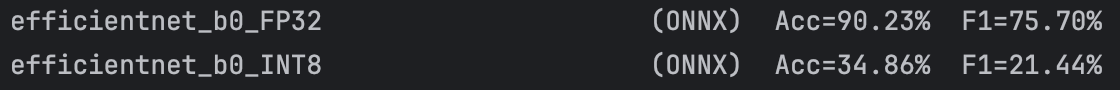

The accuracy drop is huge! The quantized ENB0 is unusable - time to find out why!

### Is it Me or the Model - Testing ResNet18

Given the poor performance of the quantized ENB0, my first thought was "is this a bug in my code, or are the results truly reflective of the model?". To ensure it wasn't a bug I trained a much simpler model, RN18 (with the exact same quantization setup) and the benchmark results were:

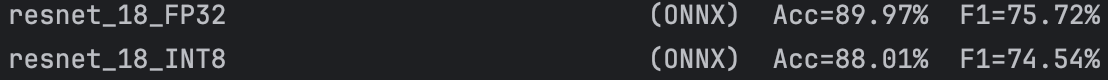

RN18 quantizes much better, indicating the issue lies with the ENB0 model itself. Note, RN18 INT8 is not immune to accuracy loss, however it's to be expected and a ~2% accuracy loss is palatable with the inference speedup.

#### Inspecting the Weight and Activation Values of ResNet18 and EfficientNetB0 Pre-Quantization

To get greater insight into how and why the models respond differently to quantization, we can pass the same input through each model <b>prior to quantization</b> and observe the values of weights and activations at each layer. At this point we're looking to see how the range of values in activations differ, the ranges and standard deviation etc. Remember that INT8 quantization can represent at most 256 values, so the wider the range of FP32 values the harder it is to fit them into the INT8 range.

In [3]:
#| code-fold: true
#| code-summary: "Run inference on pth models for inspection"

resnet_18_state_dict = "./resnet_18.pth"
efficenet_b0_state_dict = "./efficientnet_b0.pth"

def build_efficientnet_b0():
    """Build EfficientNet-B0 with custom binary classification head."""
    model = models.efficientnet_b0(weights=None)
    model.classifier = nn.Sequential(
        nn.Dropout(0.6),
        nn.Linear(1280, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.6),
        nn.Linear(128, 1),
    )
    return model

def build_resnet18():
    """Build ResNet18 with custom binary classification head."""
    model = models.resnet18(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.6),
        nn.Linear(in_features, 128),
        nn.ReLU(inplace=True),
        nn.Dropout(0.6),
        nn.Linear(128, 1),
    )
    return model

def load_weights(path):
    """Load weights, handling both raw state_dict and checkpoint formats."""
    checkpoint = torch.load(path, map_location="cpu", weights_only=False)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        return checkpoint['model_state_dict']
    return checkpoint

# ImageNet normalization
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess(face_crop: np.ndarray) -> torch.Tensor:
    """Preprocess face crop for model input."""
    img = cv2.resize(face_crop, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.transpose(2, 0, 1).astype(np.float32) / 255.0
    img = (img - mean[:, None, None]) / std[:, None, None]
    return torch.from_numpy(img).unsqueeze(0)

# Load model and saved weights into the model

resnet_model = build_resnet18()
efficientnet_model = build_efficientnet_b0()
resnet_model.load_state_dict(load_weights(resnet_18_state_dict))
efficientnet_model.load_state_dict(load_weights(efficenet_b0_state_dict))
resnet_model.eval()
efficientnet_model.eval()

input_frame = calibration_data[0]
input_frame = preprocess(input_frame)

with torch.no_grad():
    resnet_output = torch.sigmoid(resnet_model(input_frame))
    efficientnet_output = torch.sigmoid(efficientnet_model(input_frame))

Having loaded the models, and having ran a single input through both allows us to inspect the activation values at each layer.

In [ ]:
#| code-fold: true
#| code-summary: "Print raw statistics for each layer"

def get_activation_stats(model, input_tensor, model_name="Model"):
    """Capture activation statistics at ALL layers."""
    activations = {}
    hooks = []
    
    def make_hook(name):
        def hook(module, input, output):
            if isinstance(output, torch.Tensor):
                activations[name] = {
                    'shape': output.shape,
                    'min': output.min().item(),
                    'max': output.max().item(),
                    'mean': output.mean().item(),
                    'std': output.std().item() if output.numel() > 1 else 0.0,
                    'zeros_pct': (output == 0).float().mean().item() * 100,
                    'layer_type': module.__class__.__name__,
                }
        return hook
    
    # Register hooks on ALL modules (no filtering)
    for name, module in model.named_modules():
        if name:  # Skip the root module (empty name)
            hooks.append(module.register_forward_hook(make_hook(name)))
    
    # Forward pass
    with torch.no_grad():
        model(input_tensor)
    
    # Remove hooks
    for h in hooks:
        h.remove()
    
    # Print results
    print(f"\n{'='*100}")
    print(f"{model_name} Activation Statistics (ALL {len(activations)} layers)")
    print(f"{'='*100}")
    print(f"{'Layer':<40} {'Type':<15} {'Min':>9} {'Max':>9} {'Range':>9} {'Std':>9}")
    print("-" * 100)
    
    for name, stats in activations.items():
        dyn_range = stats['max'] - stats['min']
        print(f"{name:<40} {stats['layer_type']:<15} {stats['min']:>9.2f} {stats['max']:>9.2f} {dyn_range:>9.2f} {stats['std']:>9.2f}")
    
    return activations

# Re-run with ALL layers
input_tensor = preprocess(calibration_data[0])
resnet_acts = get_activation_stats(resnet_model, input_tensor, "ResNet18")
effnet_acts = get_activation_stats(efficientnet_model, input_tensor, "EfficientNet-B0")

print(f"\nTotal ResNet layers captured: {len(resnet_acts)}")
print(f"Total EfficientNet layers captured: {len(effnet_acts)}")

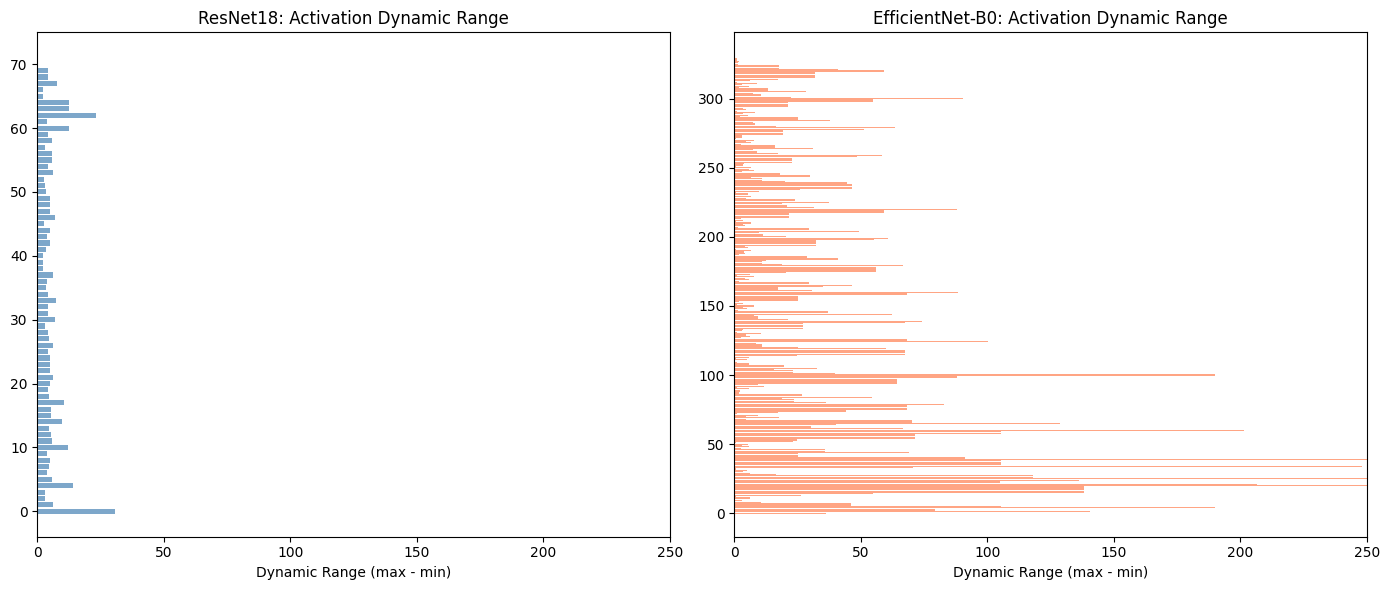


TOP 5 WORST LAYERS BY DYNAMIC RANGE

RESNET18
------------------------------------------------------------------------------------------
Rank   Layer                                      Min        Max      Range
------------------------------------------------------------------------------------------
1      conv1                                   -17.45      13.38      30.84
2      layer4.1.bn2                            -11.48      11.88      23.36
3      layer1.0.conv1                           -9.84       4.13      13.97
4      layer4.1.relu                             0.00      12.31      12.31
5      layer4.1                                  0.00      12.31      12.31

EFFICIENTNET-B0
------------------------------------------------------------------------------------------
Rank   Layer                                      Min        Max      Range
------------------------------------------------------------------------------------------
1      features.2.0.block.0.0           

In [5]:
#| code-fold: true
#| code-summary: "Visualise output of above code"

import matplotlib.pyplot as plt
import numpy as np

# Extract the key metrics from your data
def analyze_for_quantization(activations):
    """Extract quantization-relevant metrics."""
    metrics = []
    for name, stats in activations.items():
        dynamic_range = stats['max'] - stats['min']
        outlier_ratio = max(abs(stats['max']), abs(stats['min'])) / (stats['std'] + 1e-8)
        metrics.append({
            'name': name,
            'dynamic_range': dynamic_range,
            'outlier_ratio': outlier_ratio,
            'std': stats['std'],
            'max': stats['max'],
            'min': stats['min'],
            'mean': stats['mean'],
        })
    return metrics

resnet_metrics = analyze_for_quantization(resnet_acts)
effnet_metrics = analyze_for_quantization(effnet_acts)

# ============================================================
# VISUALIZATION 1: Dynamic Range Comparison (Side-by-side bars)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ResNet
resnet_ranges = [m['dynamic_range'] for m in resnet_metrics]
axes[0].barh(range(len(resnet_ranges)), resnet_ranges, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Dynamic Range (max - min)')
axes[0].set_title('ResNet18: Activation Dynamic Range')
axes[0].set_xlim(0, 250)

# EfficientNet
effnet_ranges = [m['dynamic_range'] for m in effnet_metrics]
axes[1].barh(range(len(effnet_ranges)), effnet_ranges, color='coral', alpha=0.7)
axes[1].set_xlabel('Dynamic Range (max - min)')
axes[1].set_title('EfficientNet-B0: Activation Dynamic Range')
axes[1].set_xlim(0, 250)

plt.tight_layout()
plt.savefig('dynamic_range_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# TOP 5 WORST LAYERS COMPARISON
# ============================================================

# Calculate dynamic range for each layer
resnet_layers = []
for name, stats in resnet_acts.items():
    resnet_layers.append({
        'name': name,
        'min': stats['min'],
        'max': stats['max'],
        'dynamic_range': stats['max'] - stats['min'],
        'std': stats['std']
    })

effnet_layers = []
for name, stats in effnet_acts.items():
    effnet_layers.append({
        'name': name,
        'min': stats['min'],
        'max': stats['max'],
        'dynamic_range': stats['max'] - stats['min'],
        'std': stats['std']
    })

# Sort by dynamic range (worst first)
resnet_sorted = sorted(resnet_layers, key=lambda x: x['dynamic_range'], reverse=True)
effnet_sorted = sorted(effnet_layers, key=lambda x: x['dynamic_range'], reverse=True)

# Print comparison
print()
print("="*90)
print("TOP 5 WORST LAYERS BY DYNAMIC RANGE")

print("\nRESNET18")
print("-"*90)
print(f"{'Rank':<6} {'Layer':<35} {'Min':>10} {'Max':>10} {'Range':>10}")
print("-"*90)
for i, m in enumerate(resnet_sorted[:5], 1):
    precision = m['dynamic_range'] / 256
    print(f"{i:<6} {m['name']:<35} {m['min']:>10.2f} {m['max']:>10.2f} {m['dynamic_range']:>10.2f}")

print("\nEFFICIENTNET-B0")
print("-"*90)
print(f"{'Rank':<6} {'Layer':<35} {'Min':>10} {'Max':>10} {'Range':>10}")
print("-"*90)
for i, m in enumerate(effnet_sorted[:5], 1):
    precision = m['dynamic_range'] / 256
    print(f"{i:<6} {m['name']:<35} {m['min']:>10.2f} {m['max']:>10.2f} {m['dynamic_range']:>10.2f}")

Wow, would you look at the difference! For now let's leave the actual layer differences aside and focus attention on the numbers. The big picture here is that <b>ResNet activations values are "nicer"</b> and more uniform layer to layer. The ranges don't vary wildly, the numbers themselves are much smaller and the standard deviation is much more reasonable. EfficientNet is lacking in all of these aspects and it is this which causes the poor quantization performance.

Let's dig a little deeper now, first understanding why the range matters and then go on to look at understanding which layer in the ENB0 causes the issues.

#### Why Does a Larger Range Make it Harder for INT8?

The greater range makes it harder to bin all the FP32 values into INT8 values. This can be understood further by going back to the formula for quantization:

$$
x_{q} = round(\frac{x}{S} + Z)
$$

We can use ONNX to get the $S$ and $Z$ values and manually run through some examples to see how quantization works:

In [34]:
#| code-fold: true
#| code-summary: "Code to get the S and Z given an ONNX layer name"

import onnx
import numpy as np
from onnx import numpy_helper

# ============================================================
# LOAD QUANTIZATION PARAMETERS FROM ONNX MODELS
# ============================================================

def extract_quant_params(onnx_path):
    """Extract scale and zero_point for each quantized layer."""
    model = onnx.load(onnx_path)
    initializers = {init.name: numpy_helper.to_array(init) for init in model.graph.initializer}
    
    quant_params = {}
    for name, value in initializers.items():
        if '_scale' in name:
            base_name = name.replace('_scale', '')
            if base_name not in quant_params:
                quant_params[base_name] = {}
            quant_params[base_name]['scale'] = float(value) if value.size == 1 else value
            
        elif '_zero_point' in name:
            base_name = name.replace('_zero_point', '')
            if base_name not in quant_params:
                quant_params[base_name] = {}
            quant_params[base_name]['zero_point'] = int(value) if value.size == 1 else value
    
    return quant_params

# Load from ONNX models
resnet_params = extract_quant_params('./resnet18_int8.onnx')
effnet_params = extract_quant_params('./model_int8_static.onnx')

# ============================================================
# GET SCALE AND ZERO POINT FOR WORST LAYERS
# ============================================================

# ResNet worst layer (conv1 -> bn1 -> relu output)
resnet_layer = '/relu/Relu_output_0'
resnet_scale = resnet_params[resnet_layer]['scale']
resnet_zp = resnet_params[resnet_layer]['zero_point']

# EfficientNet worst layer (features.2.0.block.0.0)
effnet_layer = '/features/features.2/features.2.0/block/block.0/block.0.0/Conv_output_0'
effnet_scale = effnet_params[effnet_layer]['scale']
effnet_zp = effnet_params[effnet_layer]['zero_point']

# ============================================================
# PRINT COMPARISON
# ============================================================

print("="*70)
print("WORST LAYER QUANTIZATION PARAMETERS (from ONNX)")
print("="*70)
print(f"\n{'Model':<20} {'Layer':<30} {'Scale':>12} {'Zero Point':>12}")
print("-"*70)
print(f"{'ResNet18':<20} {'conv1':<30} {resnet_scale:>12.6f} {resnet_zp:>12}")
print(f"{'EfficientNet-B0':<20} {'features.2.0.block.0.0':<30} {effnet_scale:>12.6f} {effnet_zp:>12}")
print("-"*70)

WORST LAYER QUANTIZATION PARAMETERS (from ONNX)

Model                Layer                                 Scale   Zero Point
----------------------------------------------------------------------
ResNet18             conv1                              0.041440         -128
EfficientNet-B0      features.2.0.block.0.0             2.531122           24
----------------------------------------------------------------------


Now given this why is it harder to represent the larger range? As mentioned, when converting to INT8 values we are binning and the larger our range is the larger our bins must be, this is why the scale is larger. Let's take a look at a concrete example:

In [164]:
#| code-fold: False
#| code-summary: "An example of why a large S value causes us to lose accuracy"

val_a = 7
val_b = 7.5

# First we quantize with the RN18 S and Z
val_a_INT8_resnet = round((val_a / resnet_scale) + resnet_zp)
val_b_INT8_resnet = round((val_b / resnet_scale) + resnet_zp)

print(f"RN18 INT8 Representation: val_a: {val_a_INT8_resnet} | val_b: {val_b_INT8_resnet}\n")

# Quantize with the ENB0 S and Z
val_a_INT8_effnet = round((val_a / effnet_scale) + effnet_zp)
val_b_INT8_effnet = round((val_b / effnet_scale) + effnet_zp)

print(f"ENB0 INT8 Representation: val_a: {val_a_INT8_effnet} | val_b: {val_b_INT8_effnet}")

ResNet18 INT8 Representation: val_a: 41 | val_b: 53

EfficientNetB0 INT8 Representation: val_a: 27 | val_b: 27


<b>The INT8 value for 7 and 7.5, with ENB0 scale and zero, is the same for both values!</b> To get a different value you would have to set the number > 7 + 2.531122 whereas for RN18 it only need be > 7 + 0.041440. This really highlights why the wild ranges cause the loss in performance, it's very difficult to maintain values as they were in the original network.

## Why ResNet18 Quantizes Well and EfficientNetB0 Doesn't - A Component by Component Analysis

So, ENB0 quantizes poorly because its activations are all over the place. The model still works well overall, it just isn't cut out for quantization. But, what causes the erratic behaviour? 

I think it's to do with the actual architecture itself, RN18 is a pretty vanilla network - its blocks are made up of Convolution, BatchNorm and ReLU[<sup>2</sup>](#2). ENB0, on the other hand has a more complicated setup - the core block is the MBConv which consists of a SiLU, convolution, depthwise convolution and a squeeze and excite operator[<sup>3</sup>](#3). There is something in this architecture causing the poorly conditioned weights and we will find it.

::: {.callout-tip collapse="True"}

##### The New Layers of EfficientNetB0

<a href="https://arxiv.org/pdf/1801.04381">DepthwiseSeparableConvolution</a> - A more efficient version of convolution, they work by splitting a single convolution into 2 layers.

<a href="https://arxiv.org/pdf/1801.04381">SiLU</a> - Similar to ReLU but it allows small negative gradients to flow through, its aim is to result in fewer dead neurons.

:::


I'll start the investigation with a simple case, 2 small networks. One will have convolution layers and the other will be with MBConv layers.

### The Investigation - Studying the Layers

The idea here is to see if passing a dummy input through an untrained model reveals anything about the differences in RN18 and ENB0 and where the wild ranges of the latter model arise from.

#### Building the models

In the expandable box you will find the code for the RN18 blocks and ENB0 blocks, we are taking 2 blocks from each model here. Then in the next box a dummy input is passed into the randomly initialised models.

In [120]:
#| code-fold: true
#| code-summary: "Code to build blocks of ResNet and EfficientNet"

class ResNetStackedModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1: 3 → 64
        self.conv1_b1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1_b1 = nn.BatchNorm2d(64)
        self.relu1_b1 = nn.ReLU()
        self.conv2_b1 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2_b1 = nn.BatchNorm2d(64)
        # Block 2: 64 → 64
        self.conv1_b2 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1_b2 = nn.BatchNorm2d(64)
        self.relu1_b2 = nn.ReLU()
        self.conv2_b2 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2_b2 = nn.BatchNorm2d(64)

    def forward(self, x):
        x = self.conv1_b1(x); x = self.bn1_b1(x); x = self.relu1_b1(x)
        x = self.conv2_b1(x); x = self.bn2_b1(x)
        x = self.conv1_b2(x); x = self.bn1_b2(x); x = self.relu1_b2(x)
        x = self.conv2_b2(x); x = self.bn2_b2(x)

        return x

class EfficientNetStackedModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1: 16 → 24 (expand to 96, squeeze to 4)
        self.conv1_expand_b1 = nn.Conv2d(16, 96, kernel_size=1, bias=False)
        self.bn1_expand_b1 = nn.BatchNorm2d(96)
        self.silu1_expand_b1 = nn.SiLU()
        self.conv2_dw_b1 = nn.Conv2d(96, 96, kernel_size=3, groups=96, padding=1, bias=False)
        self.bn2_dw_b1 = nn.BatchNorm2d(96)
        self.silu2_dw_b1 = nn.SiLU()
        self.avg_pool_b1 = nn.AdaptiveAvgPool2d(1)
        self.conv3_se_b1 = nn.Conv2d(96, 4, kernel_size=1)
        self.silu3_se_b1 = nn.SiLU()
        self.conv4_se_b1 = nn.Conv2d(4, 96, kernel_size=1)
        self.sigmoid_b1 = nn.Sigmoid()
        self.conv5_proj_b1 = nn.Conv2d(96, 24, kernel_size=1, bias=False)
        self.bn3_proj_b1 = nn.BatchNorm2d(24)

        # Block 2: 24 → 24 (expand to 144, squeeze to 6)
        self.conv1_expand_b2 = nn.Conv2d(24, 144, kernel_size=1, bias=False)
        self.bn1_expand_b2 = nn.BatchNorm2d(144)
        self.silu1_expand_b2 = nn.SiLU()
        self.conv2_dw_b2 = nn.Conv2d(144, 144, kernel_size=3, groups=144, padding=1, bias=False)
        self.bn2_dw_b2 = nn.BatchNorm2d(144)
        self.silu2_dw_b2 = nn.SiLU()
        self.avg_pool_b2 = nn.AdaptiveAvgPool2d(1)
        self.conv3_se_b2 = nn.Conv2d(144, 6, kernel_size=1)
        self.silu3_se_b2 = nn.SiLU()
        self.conv4_se_b2 = nn.Conv2d(6, 144, kernel_size=1)
        self.sigmoid_b2 = nn.Sigmoid()
        self.conv5_proj_b2 = nn.Conv2d(144, 24, kernel_size=1, bias=False)
        self.bn3_proj_b2 = nn.BatchNorm2d(24)

    def _mbconv_forward(self, x, suffix):
        x = getattr(self, f'conv1_expand_{suffix}')(x)
        x = getattr(self, f'bn1_expand_{suffix}')(x)
        x = getattr(self, f'silu1_expand_{suffix}')(x)
        x = getattr(self, f'conv2_dw_{suffix}')(x)
        x = getattr(self, f'bn2_dw_{suffix}')(x)
        x = getattr(self, f'silu2_dw_{suffix}')(x)
        x_in = x
        scale = getattr(self, f'avg_pool_{suffix}')(x)
        scale = getattr(self, f'conv3_se_{suffix}')(scale)
        scale = getattr(self, f'silu3_se_{suffix}')(scale)
        scale = getattr(self, f'conv4_se_{suffix}')(scale)
        scale = getattr(self, f'sigmoid_{suffix}')(scale)
        x = scale * x_in
        x = getattr(self, f'conv5_proj_{suffix}')(x)
        x = getattr(self, f'bn3_proj_{suffix}')(x)
        return x

    def forward(self, x):
        x = self._mbconv_forward(x, 'b1')
        x = self._mbconv_forward(x, 'b2')
        return x

In [125]:
#| code-fold: true
#| code-summary: "Passing dummy inputs into the models"

torch.manual_seed(42)
dummy_input = torch.rand(1, 3, 224, 224)

resnet_stack = ResNetStackedModel()

resnet_stack_acts = get_activation_stats(resnet_stack, dummy_input, "resnet18_block")

torch.manual_seed(42)
dummy_input = torch.rand(1, 16, 224, 224)

efficientnetb0_stack = EfficientNetStackedModel()

efficientnetb0_stack_acts = get_activation_stats(efficientnetb0_stack, dummy_input, "efficientnetb0_block")


resnet18_block Activation Statistics (ALL 10 layers)
Layer                                    Type                  Min       Max     Range       Std
----------------------------------------------------------------------------------------------------
conv1_b1                                 Conv2d              -1.26      2.02      3.28      0.34
bn1_b1                                   BatchNorm2d         -4.98      4.45      9.43      1.00
relu1_b1                                 ReLU                 0.00      4.45      4.45      0.58
conv2_b1                                 Conv2d              -2.17      2.09      4.26      0.43
bn2_b1                                   BatchNorm2d         -5.12      4.94     10.05      1.00
conv1_b2                                 Conv2d              -2.83      2.88      5.71      0.57
bn1_b2                                   BatchNorm2d         -4.69      5.08      9.77      1.00
relu1_b2                                 ReLU                 0.00   

Interesting, the activation statistics show that <b>at initialisation time both models exhibit very similar behaviour</b> - the values are well behaved and exhibit "nice" values. The outcome here doesn't fit my hypothesis. This is surprising, but it highlights that at init time there is nothing inherently bad or good about either network. Nonetheless, the issues leading to the poor quantization must appear somewhere and my next best guess is training time dynamics.

However, note that the large activation ranges appear at BatchNorm layers, and from this the next experiment will draw out exactly where and when the instability begins.

### Exploring Training Time Dynamics

To see where the instability begins, we will train both RN18 and the ENB0 models from scratch on ImageWoof[<sup>4</sup>](#4), a 10 class classification task to determine which breed a dog is. Every 5 epochs the code will log the activation min, max and std deviation values for first 2 layers in each network. This will reveal to us where and when the issue arises.

In [ ]:
#| code-fold: true
#| code-summary: "Training loop code for ImageWoof with ResNet18 and EfficientNetB0"

"""
Train ResNet18 and EfficientNet-B0 from scratch on ImageWoof (10 classes).
Log activation statistics for specific blocks every N epochs.
Save results to JSON for later analysis.

Designed to run in a Jupyter notebook on MPS.
"""

import json
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# ============================================================
# CONFIG — edit these as needed
# ============================================================
DATA_DIR = "./data/imagewoof2-320"  # <-- UPDATE THIS
BATCH_SIZE = 64
NUM_EPOCHS = 25
LOG_EVERY = 5
LR = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4
SEED = 42
OUTPUT_DIR = "./experiment_results"
NUM_WORKERS = 0  # 0 is safest on MPS, increase if stable

# ============================================================
# DEVICE SETUP
# ============================================================
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


# ============================================================
# 1. MODEL BUILDERS
# ============================================================

def build_resnet18(num_classes=10):
    """ResNet18 from scratch with simple classification head."""
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, num_classes)
    return model


def build_efficientnet_b0(num_classes=10):
    """EfficientNet-B0 from scratch with simple classification head."""
    model = models.efficientnet_b0(weights=None)
    model.classifier = nn.Sequential(
        nn.Linear(1280, num_classes),
    )
    return model


# ============================================================
# 2. DATA SETUP
# ============================================================

def get_dataloaders(data_dir, batch_size=64, num_workers=0):
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

    train_dataset = datasets.ImageFolder(
        os.path.join(data_dir, "train"),
        transform=train_transform,
    )
    val_dataset = datasets.ImageFolder(
        os.path.join(data_dir, "val"),
        transform=val_transform,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=False,  # pin_memory=False for MPS
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=False,
    )

    return train_loader, val_loader


# ============================================================
# 3. ACTIVATION LOGGING
# ============================================================

def get_activation_stats_for_blocks(model, input_tensor, block_prefixes):
    """
    Capture activation statistics for layers within specified blocks.
    """
    activations = {}
    hooks = []

    def make_hook(name):
        def hook(module, input, output):
            if isinstance(output, torch.Tensor):
                activations[name] = {
                    "shape": list(output.shape),
                    "min": output.min().item(),
                    "max": output.max().item(),
                    "mean": output.mean().item(),
                    "std": output.std().item() if output.numel() > 1 else 0.0,
                    "range": (output.max() - output.min()).item(),
                    "layer_type": module.__class__.__name__,
                }
        return hook

    for name, module in model.named_modules():
        if name and any(name.startswith(prefix) for prefix in block_prefixes):
            hooks.append(module.register_forward_hook(make_hook(name)))

    with torch.no_grad():
        model(input_tensor)

    for h in hooks:
        h.remove()

    return activations


# ============================================================
# 4. TRAINING LOOP
# ============================================================

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    return running_loss / total, 100.0 * correct / total


def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    return running_loss / total, 100.0 * correct / total


def run_experiment(
    model,
    model_name,
    block_prefixes,
    train_loader,
    val_loader,
    fixed_batch,
    device,
    num_epochs=25,
    log_every=5,
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-4,
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=momentum,
        weight_decay=weight_decay,
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    fixed_input = fixed_batch[0].to(device)

    results = {
        "model_name": model_name,
        "block_prefixes": block_prefixes,
        "hyperparameters": {
            "lr": lr,
            "momentum": momentum,
            "weight_decay": weight_decay,
            "num_epochs": num_epochs,
            "scheduler": "CosineAnnealingLR",
        },
        "training_history": [],
        "activation_logs": {},
    }

    # Log at epoch 0 (before any training)
    print(f"\n{'='*60}")
    print(f"  {model_name} — Logging activations at epoch 0 (init)")
    print(f"{'='*60}")
    model.eval()
    init_stats = get_activation_stats_for_blocks(model, fixed_input, block_prefixes)
    results["activation_logs"]["epoch_0"] = init_stats

    val_loss, val_acc = validate(model, val_loader, criterion, device)
    results["training_history"].append({
        "epoch": 0,
        "train_loss": None,
        "train_acc": None,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })
    print(f"  Epoch 0 | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # Training loop
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"  Epoch {epoch:>3d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
            f"LR: {current_lr:.6f}"
        )

        results["training_history"].append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        # Log activations every N epochs
        if epoch % log_every == 0 or epoch == num_epochs:
            print(f"  → Logging activations at epoch {epoch}")
            model.eval()
            stats = get_activation_stats_for_blocks(
                model, fixed_input, block_prefixes
            )
            results["activation_logs"][f"epoch_{epoch}"] = stats

    return results, model


# ============================================================
# 5. RUN EXPERIMENT
# ============================================================

# Data
train_loader, val_loader = get_dataloaders(
    DATA_DIR,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)
print(f"Train samples: {len(train_loader.dataset)}")
print(f"Val samples: {len(val_loader.dataset)}")
print(f"Classes: {train_loader.dataset.classes}")

# Fixed batch for consistent activation logging
fixed_batch = next(iter(val_loader))
print(f"Fixed batch shape: {fixed_batch[0].shape}")

# Shared training config
train_kwargs = dict(
    train_loader=train_loader,
    val_loader=val_loader,
    fixed_batch=fixed_batch,
    device=device,
    num_epochs=NUM_EPOCHS,
    log_every=LOG_EVERY,
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- ResNet18 ----
print("\n" + "=" * 60)
print("  TRAINING RESNET18")
print("=" * 60)
resnet = build_resnet18(num_classes=10)
resnet_results, resnet_trained = run_experiment(
    model=resnet,
    model_name="ResNet18",
    block_prefixes=["layer1.0", "layer1.1"],
    **train_kwargs,
)

resnet_path = os.path.join(OUTPUT_DIR, "resnet18_results.json")
with open(resnet_path, "w") as f:
    json.dump(resnet_results, f, indent=2)
print(f"\nResNet18 results saved to {resnet_path}")

torch.save(
    resnet_trained.state_dict(),
    os.path.join(OUTPUT_DIR, "resnet18_imagewoof.pth"),
)

# ---- EfficientNet-B0 ----
print("\n" + "=" * 60)
print("  TRAINING EFFICIENTNET-B0")
print("=" * 60)
efficientnet = build_efficientnet_b0(num_classes=10)
effnet_results, effnet_trained = run_experiment(
    model=efficientnet,
    model_name="EfficientNet-B0",
    block_prefixes=["features.1.0", "features.2.0"],
    **train_kwargs,
)

effnet_path = os.path.join(OUTPUT_DIR, "efficientnet_b0_results.json")
with open(effnet_path, "w") as f:
    json.dump(effnet_results, f, indent=2)
print(f"\nEfficientNet-B0 results saved to {effnet_path}")

torch.save(
    effnet_trained.state_dict(),
    os.path.join(OUTPUT_DIR, "efficientnet_b0_imagewoof.pth"),
)

print("\n" + "=" * 60)
print("  EXPERIMENT COMPLETE")
print("=" * 60)
print(f"All results saved to {OUTPUT_DIR}/")

Now with the output and upon further inspection, we see issues arise at the Depthwise Convs, look at the activation value after the Depthwise Conv and the subsequent BatchNorm.

In [173]:
#| code-fold: true
#| code-summary: "Load and show the training json"

import json

with open('experiment_results/resnet18_results.json') as f:
    rdata = json.load(f)
with open('experiment_results/efficientnet_b0_results.json') as f:
    edata = json.load(f)

epochs = ["epoch_0", "epoch_5", "epoch_10", "epoch_15", "epoch_20", "epoch_25"]
ep_labels = ["Ep0", "Ep5", "Ep10", "Ep15", "Ep20", "Ep25"]

def get_range(data, epoch, layer):
    return data["activation_logs"][epoch].get(layer, {}).get("range", 0)

def get_std(data, epoch, layer):
    return data["activation_logs"][epoch].get(layer, {}).get("std", 0)

def ratio(data, epoch, conv, bn):
    c = get_range(data, epoch, conv)
    b = get_range(data, epoch, bn)
    return b / c if c > 0.001 else None

def fmt(v, decimals=2):
    return f"{v:.{decimals}f}" if v is not None else "N/A"

# Table 2: Raw ranges
print("\n\nRaw Activation Ranges (Conv → BN)")
print(f"{'Layer':<32} {'Ep0':>6} {'Ep5':>6} {'Ep10':>6} {'Ep15':>6} {'Ep20':>6} {'Ep25':>6}")
print("-" * 70)
detail_rows = [
    ("ResNet Conv1",               rdata, "layer1.0.conv1"),
    ("ResNet BN1",                 rdata, "layer1.0.bn1"),
    None,
    ("EffNet Depthwise Conv",      edata, "features.2.0.block.1.0"),
    ("EffNet Depthwise BN",        edata, "features.2.0.block.1.1"),
    None,
    ("EffNet Expand Conv",         edata, "features.2.0.block.0.0"),
    ("EffNet Expand BN",           edata, "features.2.0.block.0.1"),
]
for row in detail_rows:
    if row is None:
        print()
        continue
    label, data, layer = row
    vals = [fmt(get_range(data, ep, layer), 1) for ep in epochs]
    print(f"{label:<32} {vals[0]:>6} {vals[1]:>6} {vals[2]:>6} {vals[3]:>6} {vals[4]:>6} {vals[5]:>6}")



Raw Activation Ranges (Conv → BN)
Layer                               Ep0    Ep5   Ep10   Ep15   Ep20   Ep25
----------------------------------------------------------------------
ResNet Conv1                        5.7   22.7   31.1   33.7   34.7   34.7
ResNet BN1                          5.7   15.5   19.2   17.6   19.4   19.6

EffNet Depthwise Conv               0.0    6.4    6.1    6.9    6.8    7.1
EffNet Depthwise BN                 0.0   31.6   28.8   33.2   30.2   30.5

EffNet Expand Conv                  0.3   16.7   20.4   24.0   24.3   24.8
EffNet Expand BN                    0.3   30.2   28.5   29.8   29.5   30.5


As noted, at init time both models exhibit similar behaviours. But, by epoch 5 their behaviours have diverged. In ENB0, BatchNorm is actually expanding the activation ranges! The range of values outputted by DepthWise conv is pretty reasonable, but after the BatchNorm they get crazy.

There is a <a href="https://openaccess.thecvf.com/content/CVPR2021W/MAI/papers/Yun_Do_All_MobileNets_Quantize_Poorly_Gaining_Insights_Into_the_Effect_CVPRW_2021_paper.pdf">paper</a> discussing this phenomenon in more detail, check it out for more coverage. But, we can get an insight into it by going back to the original EyesOff Models I trained.

#### Going Back to the EyesOff Models

To understand the output, we first need to better understand the DepthWise convolution. In the DepthWise conv the number of filters = number of input channels as such each filter only operates on a single input channel. Bear in mind in a regular conv each filter operates across all input channels - meaning they see much more values. Due to this, the filters of DepthWise convs can have different scales/their values can differ quite a bit across filters. This can be seen below:

In [170]:
#| code-fold: true
#| code-summary: "Compare per-channel activation mismatch and BN gamma: Depthwise Conv vs Regular Conv"

def get_per_channel_stats(model, input_tensor, layer_name):
    """Get per-channel std from activations."""
    result = {}
    hooks = []
    def make_hook(name):
        def hook(module, input, output):
            if isinstance(output, torch.Tensor):
                per_channel_std = output.std(dim=[0, 2, 3])  # [C]
                per_channel_range = output.flatten(start_dim=2).max(dim=2).values.squeeze(0) - \
                                    output.flatten(start_dim=2).min(dim=2).values.squeeze(0)  # [C]
                result["per_channel_std"] = per_channel_std
                result["per_channel_range"] = per_channel_range
        return hook
    for name, module in model.named_modules():
        if name == layer_name:
            hooks.append(module.register_forward_hook(make_hook(name)))
    with torch.no_grad():
        model(input_tensor)
    for h in hooks:
        h.remove()
    return result

# Get per-channel activation stats
resnet_ch = get_per_channel_stats(resnet_model, input_frame, "layer1.0.conv1")
effnet_ch = get_per_channel_stats(efficientnet_model, input_frame, "features.2.0.block.1.0")
r_std = resnet_ch["per_channel_std"]
e_std = effnet_ch["per_channel_std"]
r_range = resnet_ch["per_channel_range"]
e_range = effnet_ch["per_channel_range"]

# Get BN gamma values
resnet_bn_gamma = resnet_model.layer1[0].bn1.weight.data
effnet_dw_bn_gamma = efficientnet_model.features[2][0].block[1][1].weight.data

print("=" * 70)
print("  PER-CHANNEL ACTIVATION STD (output of conv layers)")
print("=" * 70)
print(f"  {'Metric':<30} {'ResNet Conv':>15} {'EffNet DW Conv':>15}")
print(f"  {'-'*60}")
print(f"  {'Num channels':<30} {r_std.shape[0]:>15} {e_std.shape[0]:>15}")
print(f"  {'Mean of ch stds':<30} {r_std.mean().item():>15.4f} {e_std.mean().item():>15.4f}")
print(f"  {'Std of ch stds':<30} {r_std.std().item():>15.4f} {e_std.std().item():>15.4f}")
print(f"  {'Min ch std':<30} {r_std.min().item():>15.4f} {e_std.min().item():>15.4f}")
print(f"  {'Max ch std':<30} {r_std.max().item():>15.4f} {e_std.max().item():>15.4f}")

print()
print("=" * 70)
print("  BATCHNORM GAMMA")
print("=" * 70)
print(f"  {'Metric':<30} {'ResNet BN1':>15} {'EffNet DW BN':>15}")
print(f"  {'-'*60}")
print(f"  {'Mean gamma':<30} {resnet_bn_gamma.mean().item():>15.4f} {effnet_dw_bn_gamma.mean().item():>15.4f}")
print(f"  {'Std of gamma':<30} {resnet_bn_gamma.std().item():>15.4f} {effnet_dw_bn_gamma.std().item():>15.4f}")
print(f"  {'Min gamma':<30} {resnet_bn_gamma.min().item():>15.4f} {effnet_dw_bn_gamma.min().item():>15.4f}")
print(f"  {'Max gamma':<30} {resnet_bn_gamma.max().item():>15.4f} {effnet_dw_bn_gamma.max().item():>15.4f}")

  PER-CHANNEL ACTIVATION STD (output of conv layers)
  Metric                             ResNet Conv  EffNet DW Conv
  ------------------------------------------------------------
  Num channels                                64              96
  Mean of ch stds                         0.4786          1.9116
  Std of ch stds                          0.2081          1.8563
  Min ch std                              0.1341          0.0118
  Max ch std                              1.0941          8.9032

  BATCHNORM GAMMA
  Metric                              ResNet BN1    EffNet DW BN
  ------------------------------------------------------------
  Mean gamma                              0.3396          5.5246
  Std of gamma                            0.1248          2.1555
  Min gamma                               0.1683          2.0408
  Max gamma                               0.6440         12.0095


Look at the difference in the mean and std deviation of the channel stats of the RN18 filters vs the ENB0 ones! Looking at the difference in min and max std deviation is even more telling - the activations of ENB0 are just bigger, this goes back to the DepthWise conv's filters, as each only operates on a single input channel they have a tendency to drift whereas the RN18 convs don't.

Next look at that BatchNorm, the range of gamma values for ENB0 is massive in comparison to RN18. In ENB0's filters the max std deviation of a channel is 8.9 whereas RN18 is much better behaved with a max std deviation across its channels of 1.08. This phenomenon is a direct outcome of the activation values ranges, the gammas need to work harder when the range is wilder. 

This then exacerbates the issues we see with INT8 quantization as gamma is a linear multiplier in the BatchNorm calculation, so with a larger gamma outliers are amplified further - thus increasing the range of values which need to be quantized. 

See below for a quick example of this, I take an example layer which just has 10 values and two of them are outliers (5 and 10) then we can see the effect of the RN18 gamma vs ENB0 gamma:

In [218]:
def simple_batch_norm(values, gamma, beta):
    mean = np.mean(values)
    variance = np.var(values)

    output = gamma * ((values - mean) / np.sqrt((variance + 1e-5))) + beta

    return output

example_activations = np.array([5, -2, 0, 2.5, 1, 1.25, 2, 3, 2.33, 10])

idx_max_gamma_enb0 = np.argmax(efficientnet_model.features[2][0].block[1][1].weight.data)
g_enb0 = efficientnet_model.features[2][0].block[1][1].weight.data[idx_max_gamma_enb0]
b_enb0 = efficientnet_model.features[2][0].block[1][1].bias.data[idx_max_gamma_enb0]

idx_max_gamma_rn18 = np.argmax(resnet_model.layer1[0].bn1.weight.data)
g_rn18 = resnet_model.layer1[0].bn1.weight.data[idx_max_gamma_rn18]
b_rn18 = resnet_model.layer1[0].bn1.bias.data[idx_max_gamma_rn18]

enb0_gamma_beta = simple_batch_norm(example_activations, g_enb0, b_enb0)
rn18_gamma_beta = simple_batch_norm(example_activations, g_rn18, b_rn18)

print(f"Range pre BatchNorm: {np.ptp(example_activations)}\n")

print("-"*90)
print("Raw actvation values post BatchNorm:\n")
print(f"ENB0: {enb0_gamma_beta}\n")
print(f"RN18: {rn18_gamma_beta}\n")
print("-"*90)

print("Range post BatchNorm:\n")
print(f"ENB0: {np.ptp(enb0_gamma_beta)}\n")
print(f"RN18: {np.ptp(rn18_gamma_beta)}\n")
print("-"*90)

Range pre BatchNorm: 12.0

------------------------------------------------------------------------------------------
Raw actvation values post BatchNorm:

ENB0: tensor([  7.2638, -20.2524, -12.3906,  -2.5634,  -8.4597,  -7.4770,  -4.5288,
         -0.5980,  -3.2317,  26.9182], dtype=torch.float64)

RN18: tensor([ 0.1996, -1.2760, -0.8544, -0.3274, -0.6436, -0.5909, -0.4328, -0.2220,
        -0.3632,  1.2536], dtype=torch.float64)

------------------------------------------------------------------------------------------
Range post BatchNorm:

ENB0: 47.17061443435465

RN18: 2.529558665151854

------------------------------------------------------------------------------------------


### Conclusion

The root cause of ENB0's poor quantization is a chain reaction: it begins with DepthWiseSeparableConvs learning 1 filter per input channel. Then without the averaging effect of operating across all channels, filters drift to different scales. Next, BatchNorm learns large gamma values due to the different scales, amplifying outliers and widening the activation range even further. Finally, when this large activation range is quantized the error is too large, causing massive degradation in performance.

Note, that this is not unique to ENB0. Any model which employs DepthWise convs may suffer the same fate. Therefore, it's worth checking the activation range of your model prior to quantizing.

As for EyesOff I am going with the RN18 model for now. I have tried QAT, but have not yet had a chance to fully test it out, also there exists other quantization methods for handling large ranges which would be worth a try. For now, RN18 is fast and accurate... what more can one from an ML model.

---

<a id="1" style="text-decoration: none; color: inherit;"><sup>1</sup></a><a href="https://huggingface.co/docs/optimum/en/concept_guides/quantization">https://huggingface.co/docs/optimum/en/concept_guides/quantization</a>

<a id="2" style="text-decoration: none; color: inherit;"><sup>2</sup></a><a href="https://docs.pytorch.org/vision/main/_modules/torchvision/models/resnet.html#ResNet18_Weights">https://docs.pytorch.org/vision/main/_modules/torchvision/models/resnet.html#ResNet18_Weights</a>

<a id="3" style="text-decoration: none; color: inherit;"><sup>3</sup></a><a href="https://docs.pytorch.org/vision/main/_modules/torchvision/models/efficientnet.html#EfficientNet_B0_Weights">https://docs.pytorch.org/vision/main/_modules/torchvision/models/efficientnet.html#EfficientNet_B0_Weights</a>

<a id="4" style="text-decoration: none; color: inherit;"><sup>4</sup></a><a href="https://github.com/fastai/imagenette">https://github.com/fastai/imagenette</a>

<a id="5" style="text-decoration: none; color: inherit;"><sup>5</sup></a> I benchmarked the power usage of the FP32 vs INT8 models and got:

```Text
=====================================================================================
  ENERGY BENCHMARK RESULTS
=====================================================================================
  Model                       Time (s)    Energy (Wh)      CO2 (g)     Wh/frame
  ---------------------------------------------------------------------------
  EfficientNet FP32               4.54         0.0612       0.0145     0.000306
  EfficientNet INT8               1.15         0.0155       0.0037     0.000077

  EfficientNet: INT8 is 3.95x faster, 74.7% less energy
```

<a id="6" style="text-decoration: none; color: inherit;"><sup>6</sup></a><a href=""></a>
